In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from arch import arch_model

#Fetching data (NIFTY)
df = yf.download("^NSEI", start="2015-01-01", end="2022-12-31", progress=False)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

if 'Adj Close' in df.columns:
    df = df[['Adj Close']].copy()
else:
    df = df[['Close']].copy()
    df.rename(columns={'Close': 'Adj Close'}, inplace=True)

# 2. Calculate Log Returns and Scale for GARCH
df['Log_Returns'] = np.log(df['Adj Close'] / df['Adj Close'].shift(1))
df.dropna(inplace=True)
df['Scaled_Returns'] = df['Log_Returns'] * 100

# 3. Split into Training (2015-2019) and Testing(2020-2022)
train_df = df.loc[:'2019-12-31'].copy()
sim_df = df.loc['2020-01-01':].copy()

print(f"Training days: {len(train_df)} | Simulation days: {len(sim_df)}")

Fetching Nifty 50 Market Data...
YF.download() has changed argument auto_adjust default to True
Training days: 1221 | Simulation days: 746


In [ ]:
class BlackScholes:
    def __init__(self, S, K, T, r, sigma):
        self.S = S          # Current Stock Price
        self.K = K          # Strike Price
        self.T = T          # Time to Expiration (in years)
        self.r = r          # Risk-free rate (e.g., 0.05)
        self.sigma = sigma  # Annualized Volatility (GARCH forecast)

    def _d1_d2(self):
        # Handle expiration day where T approaches 0 to avoid division by zero
        if self.T <= 0:
            return 0.0, 0.0
            
        d1 = (np.log(self.S / self.K) + (self.r + 0.5 * self.sigma**2) * self.T) / (self.sigma * np.sqrt(self.T))
        d2 = d1 - self.sigma * np.sqrt(self.T)
        return d1, d2

    def call_price(self):
        if self.T <= 0:
            return max(0.0, self.S - self.K)
            
        d1, d2 = self._d1_d2()
        price = self.S * norm.cdf(d1) - self.K * np.exp(-self.r * self.T) * norm.cdf(d2)
        return price

    def call_delta(self):
        if self.T <= 0:
            return 1.0 if self.S > self.K else 0.0
            
        d1, _ = self._d1_d2()
        return norm.cdf(d1)

Test Call Price: 366.14
Test Call Delta: 0.5481


In [ ]:
import warnings
warnings.filterwarnings('ignore') # Suppress GARCH convergence warnings to keep output clean (kept bugging me a lot)

# 1. Simulation Parameters
rf_rate = 0.05
transaction_cost = 0.001
refit_window = 15
option_tenor = 30

# 2. Tracking Variables
portfolio_mtm = []
unhedged_mtm = []

historical_returns = list(train_df['Scaled_Returns'].values)

active_strike = 0
days_to_expiry = 0
stock_shares = 0.0
cash = 0.0
unhedged_cash = 0.0
refit_counter = 0

#GARCH recursion state, carried forward day to day
omega = alpha = beta = None
running_var = None       # sigma_t^2, in SCALED-return units (matches historical_returns' x100 scale)
prev_scaled_return = historical_returns[-1]   # last known training-period return

for date, row in sim_df.iterrows():
    current_price = row['Adj Close']
    daily_return = row['Scaled_Returns']

    # GARCH Volatility: refit every 15 days, recurse every day
    if refit_counter == 0:
        am = arch_model(historical_returns, vol='Garch', p=1, q=1, mean='Zero')
        current_garch_result = am.fit(disp='off')

        omega = current_garch_result.params['omega']
        alpha = current_garch_result.params['alpha[1]']
        beta = current_garch_result.params['beta[1]']

        # Resume the recursion from the model's own last in-sample state,
        # so there's no discontinuity at the refit boundary.
        cv = current_garch_result.conditional_volatility
        last_cv = cv.iloc[-1] if hasattr(cv, "iloc") else cv[-1]
        running_var = last_cv ** 2

    # Daily update using yesterday's actual return (no lookahead: today's
    # daily_return hasn't been observed/used yet at this point).
    running_var = omega + alpha * (prev_scaled_return ** 2) + beta * running_var

    # Unscale (returns were x100 at fit time) and annualize.
    sigma_t = (np.sqrt(running_var) / 100) * np.sqrt(252)

    refit_counter += 1
    if refit_counter >= refit_window:
        refit_counter = 0

    historical_returns.append(daily_return)
    prev_scaled_return = daily_return   # becomes "yesterday" for tomorrow's update

    # Expiry & Rollover Logic (unchanged from Scaled notebook
    if days_to_expiry <= 0:
        if active_strike > 0:
            settlement_loss = max(0, current_price - active_strike)
            cash -= settlement_loss
            unhedged_cash -= settlement_loss

            cash += stock_shares * current_price
            cash -= abs(stock_shares * current_price) * transaction_cost
            stock_shares = 0.0

        active_strike = current_price
        days_to_expiry = option_tenor

        bs = BlackScholes(current_price, active_strike, days_to_expiry / 252, rf_rate, sigma_t)
        premium = bs.call_price()

        cash += premium
        unhedged_cash += premium

    # Daily Delta Hedge
    bs = BlackScholes(current_price, active_strike, days_to_expiry / 252, rf_rate, sigma_t)
    target_delta = bs.call_delta()

    shares_to_trade = target_delta - stock_shares
    trade_value = shares_to_trade * current_price
    trade_cost = abs(trade_value) * transaction_cost

    stock_shares = target_delta
    cash -= trade_value
    cash -= trade_cost

    # Mark-To-Market
    current_option_liability = bs.call_price()

    daily_hedged_value = cash + (stock_shares * current_price) - current_option_liability
    daily_unhedged_value = unhedged_cash - current_option_liability

    portfolio_mtm.append(daily_hedged_value)
    unhedged_mtm.append(daily_unhedged_value)

    days_to_expiry -= 1

sim_df['Hedged_MTM'] = portfolio_mtm
sim_df['Unhedged_MTM'] = unhedged_mtm


Starting Simulation Loop (2020 - 2022)... This may take 10-20 seconds.
Simulation Complete!


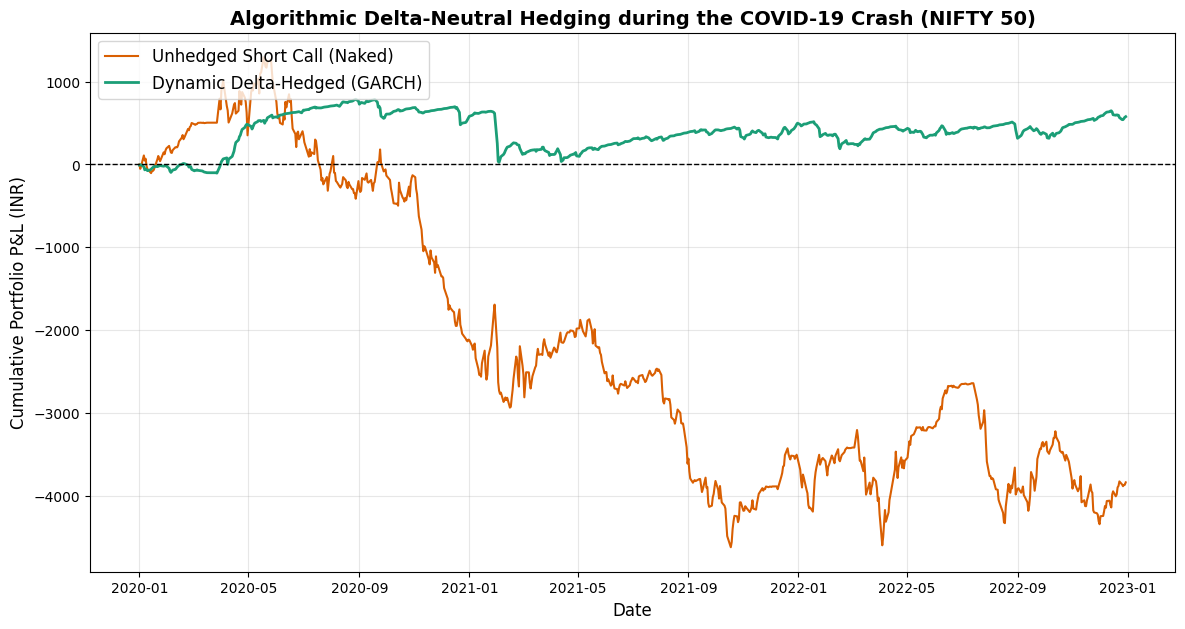

In [ ]:
import matplotlib.pyplot as plt

# Set up the plot size and style
plt.figure(figsize=(14, 7))

# Plot the Naked Short Call
plt.plot(sim_df.index, sim_df['Unhedged_MTM'], 
         color='#d95f02', linewidth=1.5, label='Unhedged Short Call (Naked)')

# Plot the Delta-Hedged Portfolio
plt.plot(sim_df.index, sim_df['Hedged_MTM'], 
         color='#1b9e77', linewidth=2, label='Dynamic Delta-Hedged (GARCH)')

# Formatting
plt.title('Algorithmic Delta-Neutral Hedging during the COVID-19 Crash (NIFTY 50)', fontsize=14, fontweight='bold')
plt.ylabel('Cumulative Portfolio P&L (INR)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.axhline(0, color='black', linewidth=1, linestyle='--') # Break-even line
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)

# DIsplay chart
plt.show()

In [ ]:
import numpy as np

# Inject a starting capital (10 Lakh INR) to calculate standard percentages
starting_capital = 1000000 
rf_rate = 0.05

print("Quantitative Performance Metrics (2020-2022)\n" + "-"*45)

for col in ['Unhedged_MTM', 'Hedged_MTM']:
    # Create a daily portfolio value series
    port_value = starting_capital + sim_df[col]
    daily_returns = port_value.pct_change().dropna()
    
    # 1. Total Return
    total_return = (port_value.iloc[-1] / starting_capital) - 1
    
    # 2. Sharpe Ratio
    excess_returns = daily_returns - (rf_rate / 252)
    sharpe_ratio = np.sqrt(252) * (excess_returns.mean() / excess_returns.std())
    
    # 3. Maximum Drawdown
    rolling_max = port_value.cummax()
    drawdown = (port_value - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    
    # Output formatting
    strategy = "Naked Short Call" if col == 'Unhedged_MTM' else "Dynamic Delta-Hedged"
    print(f"Strategy: {strategy}")
    print(f"  Total Return: {total_return * 100:.2f}%")
    print(f"  Sharpe Ratio: {sharpe_ratio:.2f}")
    print(f"  Max Drawdown: {max_drawdown * 100:.2f}%\n")

Quantitative Performance Metrics (2020-2022)
---------------------------------------------
Strategy: Naked Short Call
  Total Return: -0.38%
  Sharpe Ratio: -31.61
  Max Drawdown: -0.59%

Strategy: Dynamic Delta-Hedged
  Total Return: 0.06%
  Sharpe Ratio: -128.57
  Max Drawdown: -0.08%

